In [1]:
import os
import sys
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from models.bottleneck import Bottleneck

In [2]:
def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [3]:
def get_features(model_paths, combine_mice=True):
    all_features = []
    for model_path in model_paths:
        cp = torch.load(model_path)

        features = []
        for key, value in cp.items():
            if 'readout' in key and 'features' in key:
                features.append(value.cpu().squeeze().T)
        if combine_mice:
            features = torch.cat(features)
        
        all_features.append(features)
    return all_features

In [4]:
def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    curve = np.zeros(len(k_range))
    for x, y in zip(x_idcs, y_idcs):
        curve += knn_consistency(knns[x], knns[y], ks=k_range) 

    curve /= len(x_idcs)

    return curve

In [5]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=True, 
)

#regs = [0, 1, 3, 12, 48, 196]
regs = [4, 6, 10, 16, 24]
#barlow_ws = [20, 100, 500, 2500, 12500]
embeds = []
for i in range(len(regs)):
    embeds.append([])
    for j in range(3):
        path = f'runs/bottleneck/exp{66 + 3 * i + j}/model_weights.pth'
        print(path)
        features = get_features([path])[0]
        
        bottleneck_params = {}
        for k, v in torch.load(path).items():
            if 'readout.23343-5-17.bottleneck' in k:
                new_k = k[30:]
                bottleneck_params[new_k] = v

        bottleneck.load_state_dict(bottleneck_params)
        bottleneck.eval()

        embeds[-1].append(
            bottleneck.embed_neurons(
                features.unsqueeze(0).transpose(1, 2)
            ).squeeze().detach()
        )    

runs/bottleneck/exp66/model_weights.pth
runs/bottleneck/exp67/model_weights.pth
runs/bottleneck/exp68/model_weights.pth
runs/bottleneck/exp69/model_weights.pth
runs/bottleneck/exp70/model_weights.pth
runs/bottleneck/exp71/model_weights.pth
runs/bottleneck/exp72/model_weights.pth
runs/bottleneck/exp73/model_weights.pth
runs/bottleneck/exp74/model_weights.pth
runs/bottleneck/exp75/model_weights.pth
runs/bottleneck/exp76/model_weights.pth
runs/bottleneck/exp77/model_weights.pth
runs/bottleneck/exp78/model_weights.pth
runs/bottleneck/exp79/model_weights.pth
runs/bottleneck/exp80/model_weights.pth


In [7]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [get_curve(k_range, e) for e in embeds]

In [8]:
base_paths = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]
base_features = get_features(base_paths)
base_curve = get_curve(k_range, base_features)

In [12]:
w12_paths = [
    'runs/bottleneck/exp60/model_weights.pth', 
    'runs/bottleneck/exp61/model_weights.pth', 
    'runs/bottleneck/exp62/model_weights.pth', 
]
w12_features = get_features(w12_paths)
w12_embeds = [] 
for features, path in zip(w12_features, w12_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v

    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    w12_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )    
w12_curve = get_curve(k_range, w12_embeds)

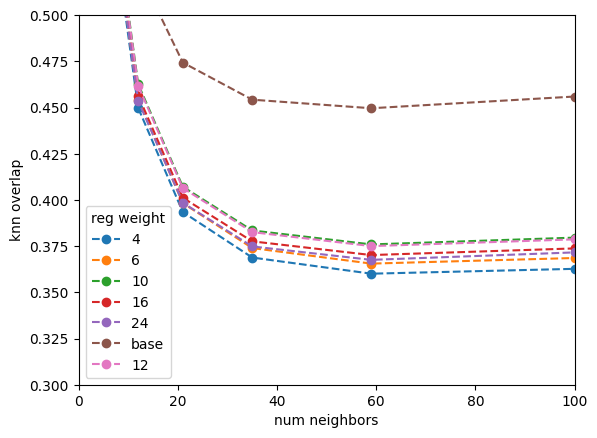

In [14]:
labels = regs
#labels = barlow_ws
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')
plt.plot(k_range, base_curve, label='base', ls='--', marker='o')
plt.plot(k_range, w12_curve, label=12, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend(title='reg weight')
#plt.legend(title='barlow weight')
plt.xlim(0, 100)
plt.ylim(0.3, 0.5)
#plt.savefig('plots/knn_overlap_bottleneck.png')
plt.show()

In [20]:
base_paths = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

bottleneck_paths = [
    'runs/bottleneck/exp0/model_weights.pth', 
    'runs/bottleneck/exp1/model_weights.pth', 
    'runs/bottleneck/exp2/model_weights.pth', 
]

weight_shared_paths = [
    'runs/bottleneck/exp3/model_weights.pth', 
    'runs/bottleneck/exp4/model_weights.pth', 
    'runs/bottleneck/exp5/model_weights.pth', 
]

no_barlow_paths = [
    'runs/bottleneck/exp6/model_weights.pth', 
    'runs/bottleneck/exp7/model_weights.pth', 
    'runs/bottleneck/exp8/model_weights.pth', 
]

weight_shared_reg_paths = [
    'runs/bottleneck/exp18/model_weights.pth', 
    'runs/bottleneck/exp19/model_weights.pth', 
    'runs/bottleneck/exp20/model_weights.pth', 
]

no_barlow_reg_paths = [
    'runs/bottleneck/exp15/model_weights.pth', 
    'runs/bottleneck/exp16/model_weights.pth', 
    'runs/bottleneck/exp17/model_weights.pth', 
]

base_features = get_features(base_paths)
bottleneck_features = get_features(bottleneck_paths)
weight_shared_features = get_features(weight_shared_paths)
no_barlow_features = get_features(no_barlow_paths)
weight_shared_reg_features = get_features(weight_shared_reg_paths)
no_barlow_reg_features = get_features(no_barlow_reg_paths)

In [6]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=False, 
)

bottleneck_embeds = []
for features, path in zip(bottleneck_features, bottleneck_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    bottleneck_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [7]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=True, 
)

weight_shared_embeds = []
for features, path in zip(weight_shared_features, weight_shared_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    weight_shared_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [8]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=True, 
)

no_barlow_embeds = []
for features, path in zip(no_barlow_features, no_barlow_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    no_barlow_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [9]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=True, 
)

weight_shared_reg_embeds = []
for features, path in zip(weight_shared_reg_features, weight_shared_reg_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    weight_shared_reg_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [10]:
bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
    weight_sharing=True, 
)

no_barlow_reg_embeds = []
for features, path in zip(no_barlow_reg_features, no_barlow_reg_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)
    bottleneck.eval()

    no_barlow_reg_embeds.append(
        bottleneck.embed_neurons(
            features.unsqueeze(0).transpose(1, 2)
        ).squeeze().detach()
    )

In [11]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curves = [
    get_curve(k_range, base_features), 
    get_curve(k_range, bottleneck_embeds), 
    get_curve(k_range, weight_shared_embeds), 
    get_curve(k_range, no_barlow_embeds), 
    get_curve(k_range, weight_shared_reg_embeds), 
    get_curve(k_range, no_barlow_reg_embeds), 
]

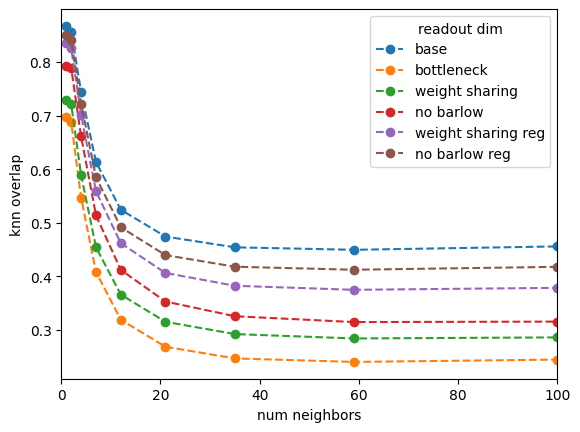

In [13]:
labels = ['base', 'bottleneck', 'weight sharing', 'no barlow', 'weight sharing reg', 'no barlow reg']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, label=label, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend(title='readout dim')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_bottleneck.png')
plt.show()

In [53]:
def get_features(paths, combine_mice=True):
    features = []
    for path in paths:
        cp = torch.load(path)
        
        f = [
            param.cpu().squeeze().T 
            for name, param in cp.items() if '_features' in name
        ]

        f = torch.cat(f) if combine_mice else f

        features.append(f)
    return features

In [54]:
def plot_eigvals(X, label, colors):
    Xc = X - X.mean(dim=0)

    _, S, _ = torch.linalg.svd(Xc, full_matrices=False)
    eigvals = (S**2) / (Xc.shape[0] - 1)

    eigvals_centered = eigvals / eigvals.sum()

    color = colors[label]
    plt.plot(np.arange(len(eigvals)) + 1, eigvals_centered, ls='-', label=label, c=color)
    plt.xlabel('eigenvalues')
    plt.ylabel('magnitude')

In [55]:
'''
pre_paths = [
    'runs/bottleneck/exp0/model_weights.pth',
    'runs/bottleneck/exp1/model_weights.pth',
    'runs/bottleneck/exp2/model_weights.pth',
]

uncompressed = get_features(pre_paths)
'''
base_paths = [
    'runs/base/exp3/model_weights.pth', 
    'runs/base/exp4/model_weights.pth', 
    'runs/base/exp5/model_weights.pth', 
]

base_features = get_features(base_paths)

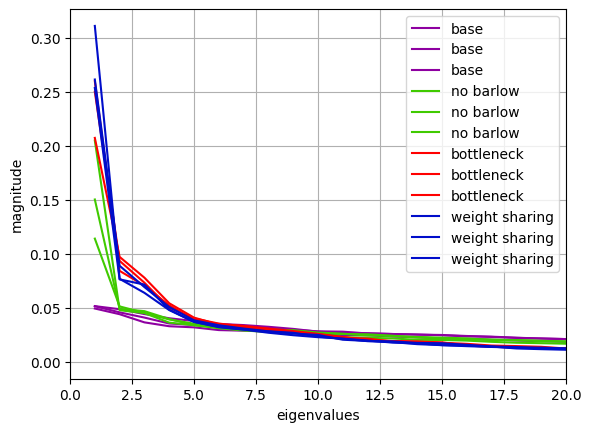

In [133]:
colors = {
    'weight sharing': "#000DCA",
    'bottleneck': "#FF0000",
    'base': "#8E00A1",
    'no barlow': "#40CA00",
}


#labels_pre = [
#    'pre bottleneck', 'pre bottleneck', 'pre bottleneck',  
#]
#[plot_eigvals(f, l, colors) for f, l in zip(bottleneck_features, labels_pre)]

[plot_eigvals(f, l, colors) for f, l in zip(base_features, ['base'] * 3)]
[plot_eigvals(f, l, colors) for f, l in zip(no_barlow_embeds, ['no barlow'] * 3)]
[plot_eigvals(f, l, colors) for f, l in zip(bottleneck_embeds, ['bottleneck'] * 3)]
[plot_eigvals(f, l, colors) for f, l in zip(weight_shared_embeds, ['weight sharing'] * 3)] 

plt.xlim(0, 20)
plt.legend()
plt.grid()
plt.savefig('plots/eigvals_bottleneck.png')
plt.show()

In [2]:
from nnfabrik.builder import get_data, get_trainer
from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from models.bottleneck import Bottleneck

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 512,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma': 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

in_dim = model_config['hidden_channels']
hidden_dims = [64]
bottleneck = Bottleneck(
    in_dim=in_dim, 
    hidden_dims=hidden_dims[:-1], 
    embedding_dim=hidden_dims[-1], 
    weight_sharing=True, 
)
for key in dataloaders['train'].keys():
    model.readout[key].bottleneck = bottleneck

model.to(device);
model.eval();

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [3]:
#model.load_state_dict(torch.load('runs/sweeps/y266q0nz/seed_0/model_weights.pth'))
model.load_state_dict(torch.load('runs/newbottle/nocomp_seed0/model_weights.pth', map_location=device))
model.eval();

In [5]:
bottleneck_features = []
num_batches = 1
keys = list(dataloaders['validation'].keys())

for key in keys:
    iterator = iter(dataloaders['validation'][key])

    embed_maps = []
    for _ in range(num_batches):
        img, _, pupil = next(iterator)

        _ = model(img, data_key=key, pupil_center=pupil)

        #embed_map = model.core(img)
        embed_map, _ = model.readout[key].bottleneck.get_last_embeds()
        embed_maps.append(embed_map.detach().cpu())

    embed_maps = torch.cat(embed_maps)
    bottleneck_features.append(embed_maps)

In [5]:
from sensorium.utility.scores import get_correlations

get_correlations(
    model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False 
)

np.float32(0.3775968)

In [18]:
bottleneck_paths = [
    'runs/bottleneck/exp48/model_weights.pth', 
    'runs/bottleneck/exp49/model_weights.pth', 
    'runs/bottleneck/exp50/model_weights.pth', 
]

no_barlow_paths = [
    'runs/bottleneck/exp15/model_weights.pth', 
    'runs/bottleneck/exp16/model_weights.pth', 
    'runs/bottleneck/exp17/model_weights.pth', 
]


with_barlow_paths = [
    'runs/bottleneck/exp18/model_weights.pth', 
    'runs/bottleneck/exp19/model_weights.pth', 
    'runs/bottleneck/exp20/model_weights.pth', 
]

In [6]:
bottleneck_features = []
num_batches = 5
keys = list(dataloaders['train'].keys())

for key in keys:
    iterator = iter(dataloaders['train'][key])

    embed_maps = []
    for _ in range(num_batches):
        img, _, _, pupil = next(iterator)

        _ = model(img, data_key=key, pupil_center=pupil)

        #embed_map = model.core(img)
        embed_map, _ = model.readout[key].bottleneck.get_last_embeds()
        embed_maps.append(embed_map.detach().cpu())

    embed_maps = torch.cat(embed_maps)
    bottleneck_features.append(embed_maps)

ValueError: not enough values to unpack (expected 4, got 3)

In [ ]:
torch.cat(bottleneck_features)

torch.Size([17920, 48, 26, 54])

In [24]:
X = torch.cat(bottleneck_features).permute(0, 2, 3, 1).flatten(0, 2)
#X = bottleneck_features[6].permute(0, 2, 3, 1).flatten(0, 2)

Xc = X - X.mean(dim=0, keepdim=True)
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

std = Xc.std(dim=0, keepdim=True)
corr = cov / (std.T @ std)

/tmp/ipykernel_25296/2869974333.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = np.abs(cov) < 0.3
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1500x1500 with 0 Axes>

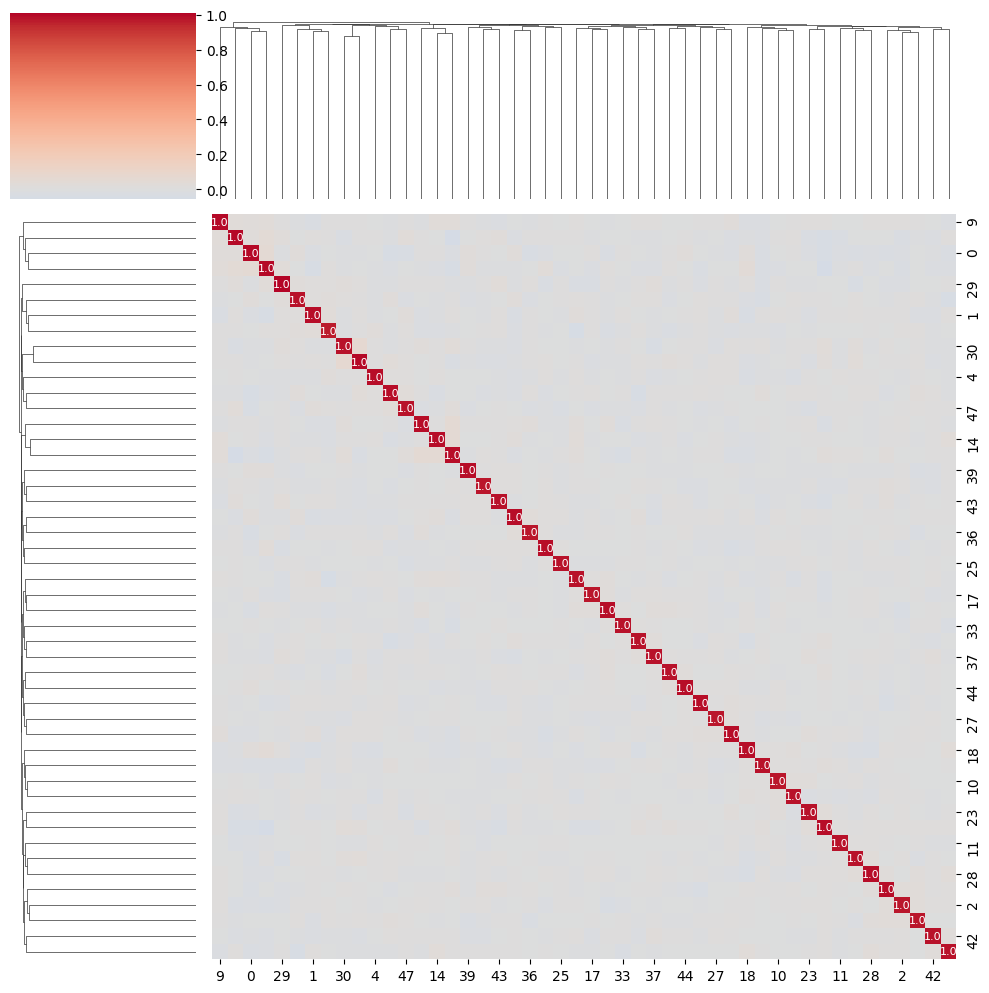

In [25]:
plt.figure(figsize=(15, 15))

mask = np.abs(cov) < 0.3

heatmap = sns.clustermap(
    cov,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}, 
    annot=np.where(mask, '', np.round(cov, 1)),
    fmt='', 
    annot_kws={'size': 8}, 
)
plt.tight_layout()
plt.savefig('plots/bottleneck_channel_correlations.png')
plt.show()

In [22]:
# per mouse embeds

In [70]:
base_paths = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

bottleneck_paths = [
    'runs/bottleneck/exp0/model_weights.pth', 
    'runs/bottleneck/exp1/model_weights.pth', 
    'runs/bottleneck/exp2/model_weights.pth', 
]

base_features = get_features(base_paths, combine_mice=False)
bottleneck_features = get_features(bottleneck_paths, combine_mice=False)

In [71]:
from models.bottleneck import Bottleneck

bottleneck = Bottleneck(
    in_dim=64, 
    hidden_dims=[256], 
    embedding_dim=48, 
)

bottleneck_embeds = []
for features, path in zip(bottleneck_features, bottleneck_paths):
    bottleneck_params = {}
    for k, v in torch.load(path).items():
        if 'readout.23343-5-17.bottleneck' in k:
            new_k = k[30:]
            bottleneck_params[new_k] = v
            
    bottleneck.load_state_dict(bottleneck_params)

    fs = []
    for f_mouse in features:
        fs.append(
            bottleneck.embed_neurons(
                f_mouse.unsqueeze(0).transpose(1, 2)
            ).squeeze().detach()
    )
    bottleneck_embeds.append(fs)

In [72]:
n = 2000
filtered_bottleneck = []
for features in bottleneck_embeds:
    fs = []

    for f_mouse in features:
        idcs = torch.randperm(f_mouse.shape[0])
        fs.append(f_mouse[idcs[:n]])

    filtered_bottleneck.append(torch.cat(fs))

In [73]:
base_features_per_mouse = get_features(base_paths, combine_mice=False)

base_features = []
for seed_features in base_features_per_mouse:
    fs = []
    for f in seed_features:
        idcs = torch.randperm(f.shape[0])
        fs.append(f[idcs[:n]])
        
    base_features.append(torch.cat(fs))

In [80]:
def plot_tsne(X):
    n = X.shape[0]
    perplexity = n / 100
    lr = n / 12
    early_exaggeration = 12

    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
    X_tsne = tsne.fit_transform(X)  # Run on unnormalized data

    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=1)

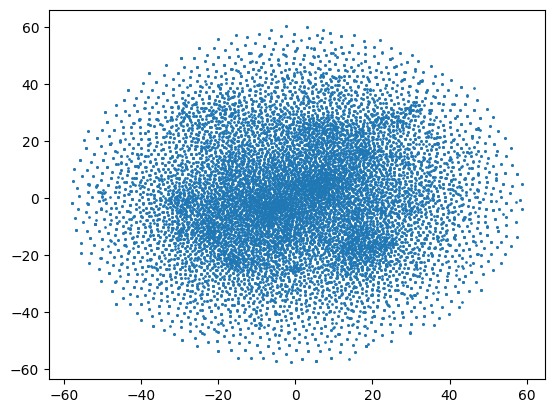

In [ ]:
plot_tsne(base_features[0])

plt.show()

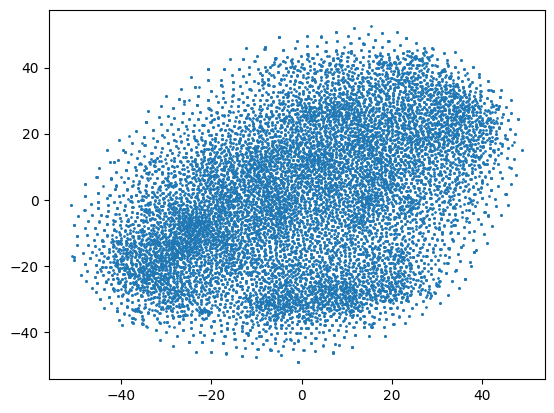

In [79]:
plot_tsne(filtered_bottleneck[0])